# FWHT Compression for PSD Acquisitions

This notebook implements the deterministic FWHT codec proposed in
[`docs/main.tex`](../docs/main.tex) for the PSD acquisitions bundled in
this repository.

**System boundary**
- The tested codec core now lives in [`neural_compression/fwht_codec.py`](../neural_compression/fwht_codec.py).
- The notebook is intentionally thin: it loads the PSD dataset, runs the
  payload-only codec, evaluates sensing-oriented metrics, and plots the
  rate-distortion trade-off.
- Decoder reconstruction now depends only on transmitted payload fields:
  retained coefficient indices, quantized coefficient levels, the float32
  scale used to dequantize them, and the float32 standardization side
  information plus shape metadata.

**Important modeling choices**
- The PSD values stored in the repository are already in dB, but the
  default decimation step averages adjacent bins in **linear power**
  before mapping back to dB. This removes the main physical mismatch of
  averaging dB values directly.
- Occupancy is evaluated with the same noise-floor rule applied
  independently to the original and reconstructed PSD, which removes the
  original-threshold leakage from the previous version.
- Connected occupied regions are extracted before measuring occupied
  bandwidth, so multi-emission scenes are no longer reduced to one large
  span from the first station to the last station.

## Imports and Repository Paths

In [20]:
from __future__ import annotations

import sys
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "neural_compression" / "fwht_codec.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from neural_compression.fwht_codec import (  # noqa: E402
    DatasetConfig,
    FWHTCodecConfig,
    compute_frame_metrics,
    estimate_noise_floor_db,
    estimate_payload_bits,
    evaluate_codec_dataset,
    load_psd_frames,
    materialize_sparse_coefficients,
    reconstruct_fwht_frame,
    select_representative_frame,
    summarize_results,
)

DATA_ROOT = PROJECT_ROOT / "data" / "RBW_acquisitions"
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Could not locate the RBW acquisitions directory from {PROJECT_ROOT}"
    )

## Load the PSD Dataset

In [21]:
DATASET_CONFIG = DatasetConfig(
    dataset_dir=DATA_ROOT / "100K",
    max_frames=None,
    noise_floor_percentile=20.0,
    occupancy_margin_db=3.0,
)
DEFAULT_CODEC_CONFIG = FWHTCodecConfig(
    decimation_factor=2,
    retained_coefficients=64,
    quantization_bits=8,
    nonlinear_map="identity",
    aggregation_domain="linear_power",
)

frames = load_psd_frames(DATASET_CONFIG)
dataset_overview_df = pd.DataFrame(
    {
        "num_frames": [len(frames)],
        "num_files": [len(list(DATASET_CONFIG.dataset_dir.glob("*.csv")))],
        "bins_per_frame": [frames[0].psd_db.size],
        "frequency_start_mhz": [frames[0].start_freq_hz / 1e6],
        "frequency_end_mhz": [frames[0].end_freq_hz / 1e6],
        "aggregation_domain": [DEFAULT_CODEC_CONFIG.aggregation_domain],
        "default_decimation_factor": [DEFAULT_CODEC_CONFIG.decimation_factor],
        "default_retained_coefficients": [DEFAULT_CODEC_CONFIG.retained_coefficients],
        "default_quantization_bits": [DEFAULT_CODEC_CONFIG.quantization_bits],
    }
)
dataset_overview_df

,num_frames,num_files,bins_per_frame,frequency_start_mhz,frequency_end_mhz,aggregation_domain,default_decimation_factor,default_retained_coefficients,default_quantization_bits
0,145,5,512,88.0,108.0,linear_power,2,64,8


## Single-Frame Reconstruction Example

In [22]:
sample_frame = select_representative_frame(frames, DATASET_CONFIG)
sample_payload, sample_diagnostics, sample_reconstructed_psd_db = (
    reconstruct_fwht_frame(
        sample_frame,
        DEFAULT_CODEC_CONFIG,
    )
)
sample_payload_bits = estimate_payload_bits(sample_payload, DEFAULT_CODEC_CONFIG)
sample_metrics = compute_frame_metrics(
    frame=sample_frame,
    reconstructed_psd_db=sample_reconstructed_psd_db,
    dataset_config=DATASET_CONFIG,
    payload_bits=sample_payload_bits,
    codec_config=DEFAULT_CODEC_CONFIG,
)

sample_metrics_df = pd.DataFrame([asdict(sample_metrics)])
sample_metrics_df

,rmse_db,nmse,occupancy_f1,occupancy_false_negative_rate,occupancy_false_positive_rate,peak_error_hz,centroid_error_hz,occupied_bandwidth_error_hz,payload_bits,compression_ratio
0,5.181,0.009,0.866,0.101,0.241,0.0,320557.421,859375.0,1168,14.027


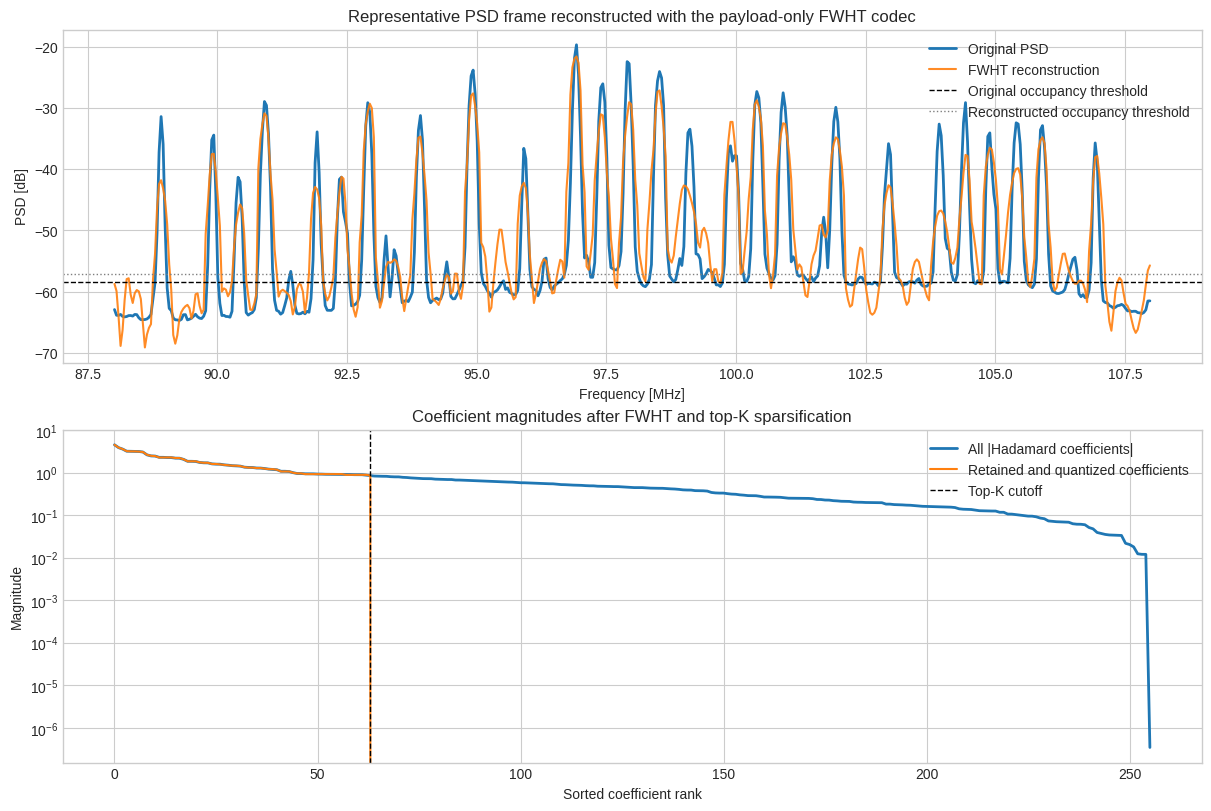

In [23]:
sample_frequency_mhz = sample_frame.frequencies_hz / 1e6
reference_noise_floor_db = estimate_noise_floor_db(
    sample_frame.psd_db,
    DATASET_CONFIG.noise_floor_percentile,
)
reconstructed_noise_floor_db = estimate_noise_floor_db(
    sample_reconstructed_psd_db,
    DATASET_CONFIG.noise_floor_percentile,
)
reference_threshold_db = reference_noise_floor_db + DATASET_CONFIG.occupancy_margin_db
reconstructed_threshold_db = (
    reconstructed_noise_floor_db + DATASET_CONFIG.occupancy_margin_db
)

sorted_dense_coefficients = np.sort(np.abs(sample_diagnostics.dense_coefficients))[::-1]
sorted_sparse_coefficients = np.sort(
    np.abs(materialize_sparse_coefficients(sample_payload, DEFAULT_CODEC_CONFIG))
)[::-1]

figure, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

# The top panel compares the original and reconstructed PSD directly on the sensing grid.
axes[0].plot(
    sample_frequency_mhz,
    sample_frame.psd_db,
    label="Original PSD",
    linewidth=2.0,
)
axes[0].plot(
    sample_frequency_mhz,
    sample_reconstructed_psd_db,
    label="FWHT reconstruction",
    linewidth=1.5,
    alpha=0.9,
)
axes[0].axhline(
    reference_threshold_db,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Original occupancy threshold",
)
axes[0].axhline(
    reconstructed_threshold_db,
    color="tab:gray",
    linestyle=":",
    linewidth=1.0,
    label="Reconstructed occupancy threshold",
)
axes[0].set_title(
    "Representative PSD frame reconstructed with the payload-only FWHT codec"
)
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("PSD [dB]")
axes[0].legend(loc="best")

# The bottom panel shows why the codec works: the Hadamard coefficients are sparse enough for top-K retention.
axes[1].plot(
    sorted_dense_coefficients,
    label="All |Hadamard coefficients|",
    linewidth=2.0,
)
axes[1].plot(
    sorted_sparse_coefficients,
    label="Retained and quantized coefficients",
    linewidth=1.5,
)
axes[1].axvline(
    DEFAULT_CODEC_CONFIG.retained_coefficients - 1,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Top-K cutoff",
)
axes[1].set_title("Coefficient magnitudes after FWHT and top-K sparsification")
axes[1].set_xlabel("Sorted coefficient rank")
axes[1].set_ylabel("Magnitude")
axes[1].set_yscale("log")
axes[1].legend(loc="best")

plt.show()

## Dataset-Level Rate-Distortion Sweep

In [24]:
retained_coefficients_grid = [4, 8, 16, 32, 64, 128, 256]
codec_grid = [
    replace(DEFAULT_CODEC_CONFIG, retained_coefficients=retained_coefficients)
    for retained_coefficients in retained_coefficients_grid
]

frame_results_df = evaluate_codec_dataset(
    frames=frames,
    dataset_config=DATASET_CONFIG,
    codec_configs=codec_grid,
)
sweep_summary_df = summarize_results(frame_results_df)
sweep_summary_df

,decimation_factor,nonlinear_map,aggregation_domain,quantization_bits,retained_coefficients,mean_rmse_db,mean_nmse,mean_occupancy_f1,mean_peak_error_hz,mean_centroid_error_hz,mean_bandwidth_error_hz,mean_payload_bits,mean_compression_ratio,mean_payload_bytes
0,2,identity,linear_power,8,4,8.340,0.023,0.661,6.228e+06,1.339e+06,4.704e+06,208.0,78.769,26.0
1,2,identity,linear_power,8,8,7.592,0.019,0.714,4.683e+06,1.292e+06,3.579e+06,272.0,60.235,34.0
2,2,identity,linear_power,8,16,6.649,0.014,0.744,3.269e+06,8.800e+05,4.263e+06,400.0,40.960,50.0
3,2,identity,linear_power,8,32,5.465,0.010,0.773,3.059e+06,9.976e+05,3.603e+06,656.0,24.976,82.0
4,2,identity,linear_power,8,64,4.575,0.007,0.805,2.888e+06,5.481e+05,2.735e+06,1168.0,14.027,146.0
5,2,identity,linear_power,8,128,3.849,0.005,0.869,2.823e+06,1.941e+05,1.792e+06,2192.0,7.474,274.0
6,2,identity,linear_power,8,256,3.731,0.004,0.889,7.082e+05,1.786e+04,1.453e+06,4240.0,3.864,530.0


In [25]:
feasible_rows = sweep_summary_df.loc[sweep_summary_df["mean_occupancy_f1"] >= 0.80]
if feasible_rows.empty:
    recommended_row = sweep_summary_df.sort_values(
        ["mean_occupancy_f1", "mean_rmse_db"],
        ascending=[False, True],
    ).iloc[0]
else:
    recommended_row = feasible_rows.sort_values(
        ["mean_payload_bits", "mean_rmse_db"]
    ).iloc[0]

recommended_operating_point_df = pd.DataFrame([recommended_row]).reset_index(drop=True)
recommended_operating_point_df

,decimation_factor,nonlinear_map,aggregation_domain,quantization_bits,retained_coefficients,mean_rmse_db,mean_nmse,mean_occupancy_f1,mean_peak_error_hz,mean_centroid_error_hz,mean_bandwidth_error_hz,mean_payload_bits,mean_compression_ratio,mean_payload_bytes
0,2,identity,linear_power,8,64,4.575,0.007,0.805,2.888e+06,548144.19,2.735e+06,1168.0,14.027,146.0


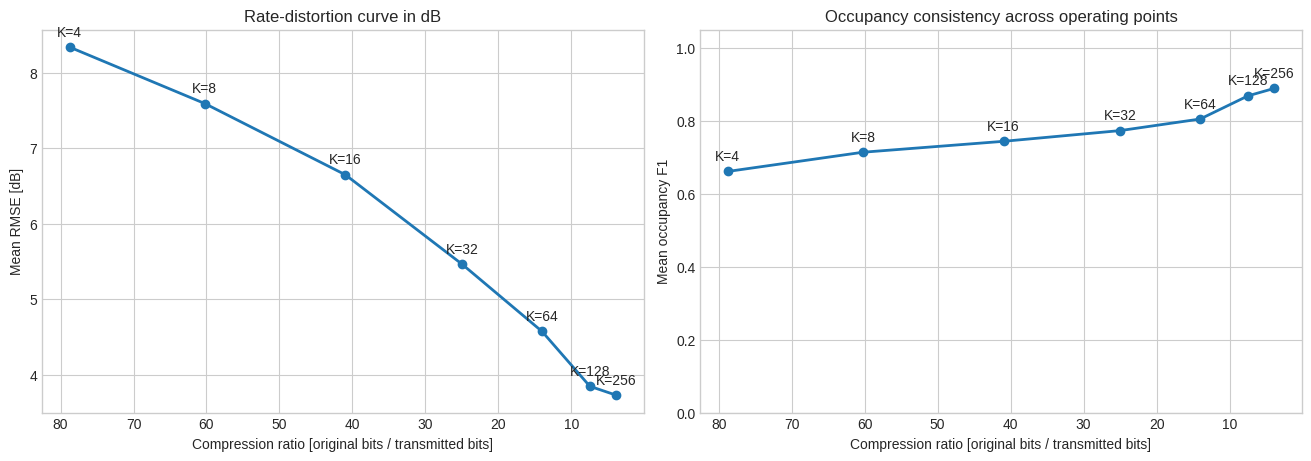

In [26]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

# RMSE captures waveform fidelity, while occupancy F1 captures the sensing decision quality.
axes[0].plot(
    sweep_summary_df["mean_compression_ratio"],
    sweep_summary_df["mean_rmse_db"],
    marker="o",
    linewidth=2.0,
)
axes[0].set_title("Rate-distortion curve in dB")
axes[0].set_xlabel("Compression ratio [original bits / transmitted bits]")
axes[0].set_ylabel("Mean RMSE [dB]")
axes[0].invert_xaxis()

axes[1].plot(
    sweep_summary_df["mean_compression_ratio"],
    sweep_summary_df["mean_occupancy_f1"],
    marker="o",
    linewidth=2.0,
)
axes[1].set_title("Occupancy consistency across operating points")
axes[1].set_xlabel("Compression ratio [original bits / transmitted bits]")
axes[1].set_ylabel("Mean occupancy F1")
axes[1].set_ylim(0.0, 1.05)
axes[1].invert_xaxis()

for _, row in sweep_summary_df.iterrows():
    label = f"K={int(row['retained_coefficients'])}"
    axes[0].annotate(
        label,
        (row["mean_compression_ratio"], row["mean_rmse_db"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )
    axes[1].annotate(
        label,
        (row["mean_compression_ratio"], row["mean_occupancy_f1"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

plt.show()

## Takeaway

The notebook now evaluates an honest codec boundary: the decoder rebuilds the
sparse Hadamard-domain vector from the transmitted payload instead of
relying on encoder-side helper arrays. Side information is quantized to
float32 before reconstruction, occupancy metrics no longer leak the
original threshold into the reconstructed path, and occupied bandwidth is
computed from connected components instead of a full-band span.